##Cell 1 — Mount Google Drive





In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")

Mounted at /content/drive
Drive mounted successfully!


##  Cell 2 — Extract Dataset from ZIP

In [2]:
import zipfile
import os

zip_path    = "/content/drive/MyDrive/CourseworkAI/Skin Cancer Classification-20260430T074553Z-3-001.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")
print(os.listdir(extract_path))

Unzipped successfully!
['Skin Cancer Classification']


##  Cell 3 — Import All Libraries

In [3]:
import os, random, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from PIL import Image, UnidentifiedImageError

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("All imports done!")

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All imports done!


##  Cell 4 — Global Configuration

In [4]:
BASE_DIR  = '/content/data/Skin Cancer Classification'
TRAIN_DIR = os.path.join(BASE_DIR, 'Train')
TEST_DIR  = os.path.join(BASE_DIR, 'Test')

IMG_HEIGHT       = 128
IMG_WIDTH        = 128
BATCH_SIZE       = 32
VALIDATION_SPLIT = 0.2
AUTOUNE          = tf.data.AUTOTUNE

# Epoch counts
EPOCHS_BASELINE  = 50
EPOCHS_DEEP      = 50
EPOCHS_TRANSFER  = 15

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Image size : {IMG_HEIGHT} x {IMG_WIDTH}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Val split  : {VALIDATION_SPLIT}")

Classes (9): ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Image size : 128 x 128
Batch size : 32
Val split  : 0.2


##  Cell 5 — Dataset Description & Class Distribution

In [5]:

print("DATASET DESCRIPTION")

print("""
Dataset  : Skin Cancer MNIST (HAM10000 / ISIC)
Task     : Multi-class Image Classification
Source   : Kaggle / ISIC Archive
Purpose  : Classify skin lesions into diagnostic
           categories to assist dermatologists in
           early cancer detection.
""")

class_counts = {}
total_train  = 0

print(f"{'Class':<35} {'Train Images':>12}")
print("-" * 50)
for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    n = len([f for f in os.listdir(cls_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[cls] = n
    total_train += n
    print(f"  {cls:<33} {n:>12}")


print(f"  {'TOTAL':<33} {total_train:>12}")
print()

# Test set count
total_test = 0
for cls in CLASS_NAMES:
    cls_path = os.path.join(TEST_DIR, cls)
    if os.path.isdir(cls_path):
        total_test += len([f for f in os.listdir(cls_path)
                           if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
print(f"Total test images  : {total_test}")
print(f"Total dataset size : {total_train + total_test}")
print()
print("Split strategy:")
print(f"  Training   : {int(total_train * (1-VALIDATION_SPLIT))} images  (~{int((1-VALIDATION_SPLIT)*100)}%)")
print(f"  Validation : {int(total_train * VALIDATION_SPLIT)}  images  (~{int(VALIDATION_SPLIT*100)}%)")
print(f"  Test       : {total_test} images (held-out)")

DATASET DESCRIPTION

Dataset  : Skin Cancer MNIST (HAM10000 / ISIC)
Task     : Multi-class Image Classification
Source   : Kaggle / ISIC Archive
Purpose  : Classify skin lesions into diagnostic
           categories to assist dermatologists in
           early cancer detection.

Class                               Train Images
--------------------------------------------------
  actinic keratosis                          114
  basal cell carcinoma                       376
  dermatofibroma                              95
  melanoma                                   438
  nevus                                      357
  pigmented benign keratosis                 462
  seborrheic keratosis                        77
  squamous cell carcinoma                    181
  vascular lesion                            139
  TOTAL                                     2239

Total test images  : 118
Total dataset size : 2357

Split strategy:
  Training   : 1791 images  (~80%)
  Validation : 447  images

##  Cell 6 — Class Distribution Visualisation

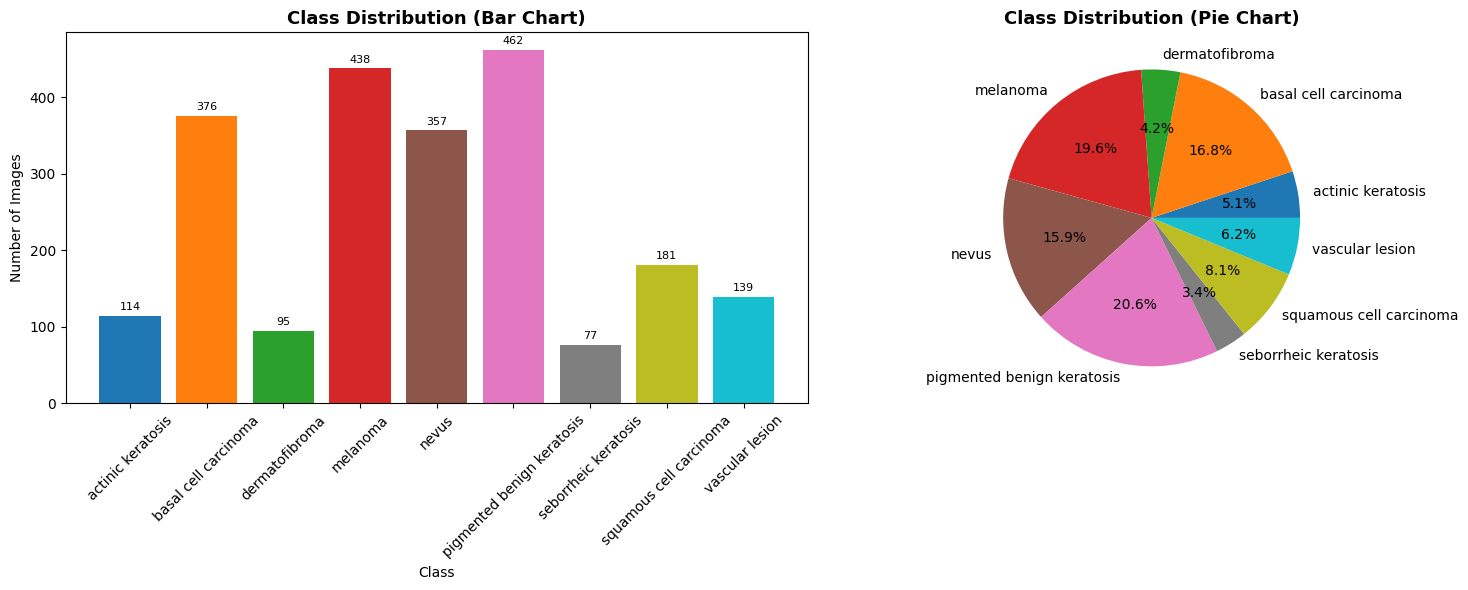


Key Observations:
  • Most frequent class  : 'pigmented benign keratosis' (462 images)
  • Least frequent class : 'seborrheic keratosis' (77 images)
  • Imbalance ratio      : 6.0x
  • Dataset is significantly imbalanced — class weights will be used during training.


In [6]:
classes = list(class_counts.keys())
counts  = list(class_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
bars = axes[0].bar(classes, counts, color=colors)
axes[0].set_title("Class Distribution (Bar Chart)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontsize=8)

# Pie chart
axes[1].pie(counts, labels=classes, autopct='%1.1f%%', colors=colors)
axes[1].set_title("Class Distribution (Pie Chart)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
max_cls = max(class_counts, key=class_counts.get)
min_cls = min(class_counts, key=class_counts.get)
print(f"  • Most frequent class  : '{max_cls}' ({class_counts[max_cls]} images)")
print(f"  • Least frequent class : '{min_cls}' ({class_counts[min_cls]} images)")
print(f"  • Imbalance ratio      : {class_counts[max_cls]/class_counts[min_cls]:.1f}x")
print("  • Dataset is significantly imbalanced — class weights will be used during training.")

##  Cell 7 — Sample Images Per Class

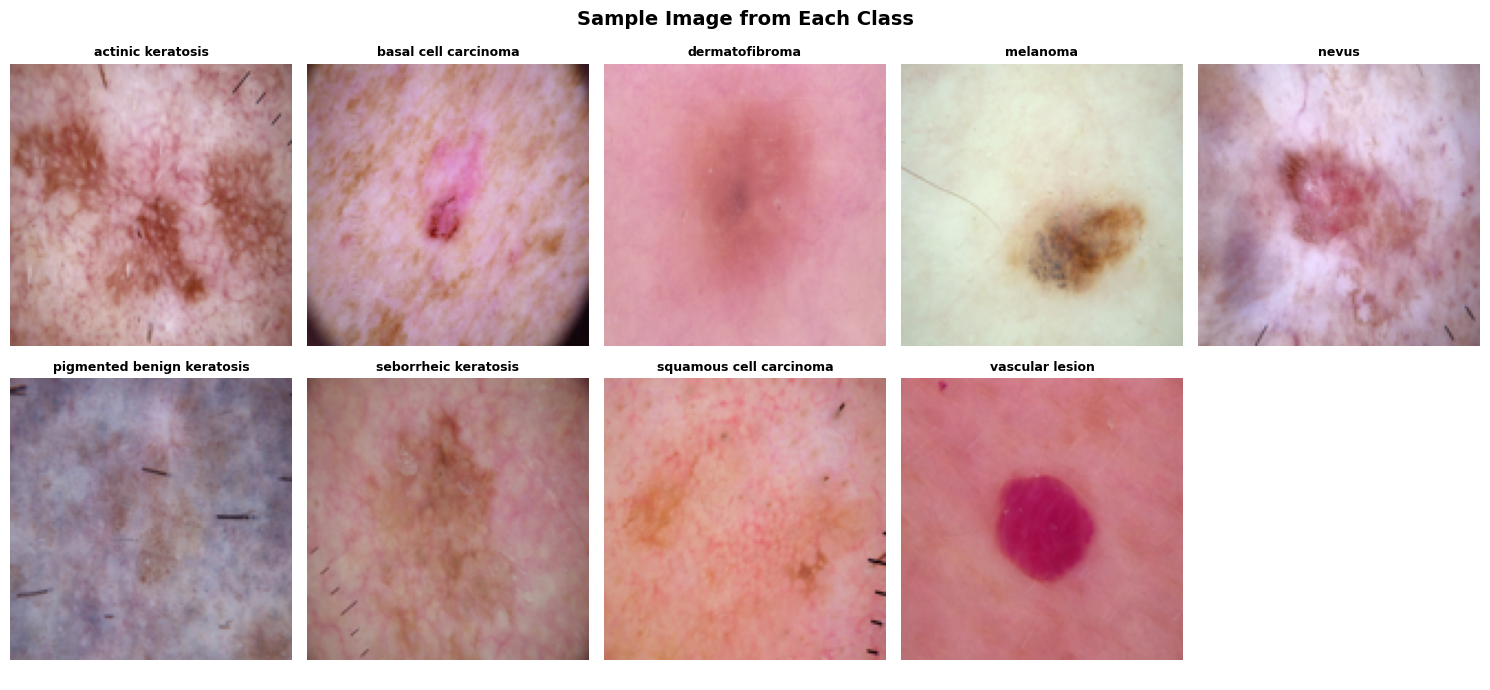

In [7]:
random.seed(SEED)
n_classes = len(CLASS_NAMES)
cols = (n_classes + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 3, 7))
axes = axes.flatten()
fig.suptitle("Sample Image from Each Class", fontsize=14, fontweight='bold')

for i, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    img = None
    for _ in range(10):
        if not images:
            break
        try:
            img_path = os.path.join(cls_path, random.choice(images))
            img = Image.open(img_path).convert("RGB").resize((128, 128))
            break
        except (UnidentifiedImageError, IOError):
            images.remove(os.path.basename(img_path))
    if img is not None:
        axes[i].imshow(img)
    else:
        axes[i].text(0.5, 0.5, "Corrupted", ha='center', va='center')
    axes[i].set_title(cls, fontsize=9, fontweight='bold')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('sample_images_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

##  Cell 8 — Data Cleaning: Remove Corrupted Images

In [8]:
def remove_corrupted_images(directory, label='Directory'):
    corrupted = []
    extensions = ('.jpg', '.jpeg', '.png')
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            if not fname.lower().endswith(extensions):
                continue
            img_path = os.path.join(cls_path, fname)
            try:
                img = Image.open(img_path)
                img.verify()
            except Exception:
                corrupted.append(img_path)
                os.remove(img_path)
                print(f"  Removed: {img_path}")
    if len(corrupted) == 0:
        print(f"  [{label}] No corrupted images found. ✓")
    else:
        print(f"  [{label}] Total removed: {len(corrupted)}")
    return corrupted

print("Checking TRAIN directory...")
remove_corrupted_images(TRAIN_DIR, 'TRAIN')
print("Checking TEST directory...")
remove_corrupted_images(TEST_DIR, 'TEST')
print("\nData cleaning complete!")

Checking TRAIN directory...
  Removed: /content/data/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0028449.jpg
  Removed: /content/data/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0026867.jpg
  Removed: /content/data/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0027770.jpg
  Removed: /content/data/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0027151.jpg
  Removed: /content/data/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0027680.jpg
  Removed: /content/data/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0024626.jpg
  Removed: /content/data/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0025777.jpg
  Removed: /content/data/Skin Cancer Classification/Train/melanoma/ISIC_0010486.jpg
  Removed: /content/data/Skin Cancer Classification/Train/melanoma/ISIC_0000308.jpg
  Removed: /content/data/Skin Cancer Classification/Train/melanoma/ISIC_0010579.jpg
  Remo

##  Cell 9 — Build Data Pipeline with Normalisation & Augmentation

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
rescale  = tf.keras.layers.Rescaling(1.0 / 255)

# Data Augmentation Layer (applied ONLY to training data)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    #layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name='augmentation')

#  Load raw datasets
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred', label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED
)

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred', label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED
)

test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred', label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

#  Apply normalisation + augmentation to training, normalisation only to val/test
# FIX: augmentation is now properly applied inside the pipeline
train_ds = train_ds_raw.map(
    lambda x, y: (data_augmentation(rescale(x), training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds = val_ds_raw.map(
    lambda x, y: (rescale(x), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_ds = test_ds_raw.map(
    lambda x, y: (rescale(x), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

print(f"Train batches      : {len(train_ds)}")
print(f"Validation batches : {len(val_ds)}")
print(f"Test batches       : {len(test_ds)}")
print()
print("Preprocessing applied:")
print("  • Pixel rescaling to [0, 1]")
print("  • Augmentation (train only): H/V flip, rotation, zoom, brightness, contrast")
print("  • Prefetching for performance")

Found 2176 files belonging to 9 classes.
Using 1741 files for training.
Found 2176 files belonging to 9 classes.
Using 435 files for validation.
Found 118 files belonging to 9 classes.
Train batches      : 55
Validation batches : 14
Test batches       : 4

Preprocessing applied:
  • Pixel rescaling to [0, 1]
  • Augmentation (train only): H/V flip, rotation, zoom, brightness, contrast
  • Prefetching for performance


##  Cell 10 — Augmentation Visualisation

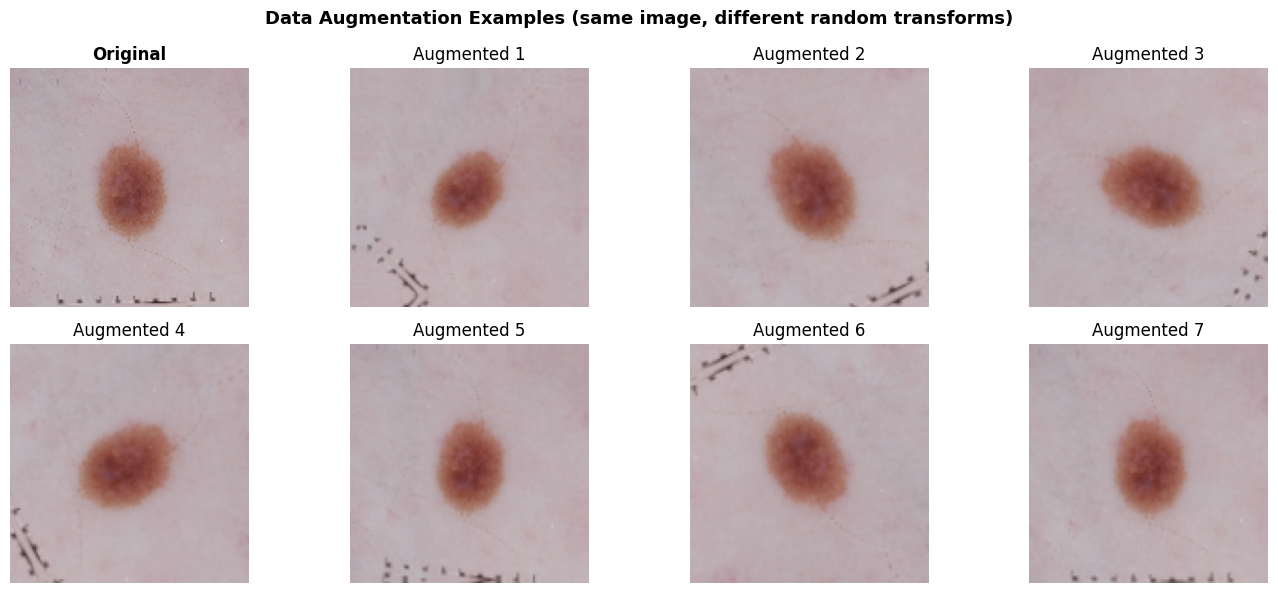

Augmentation applied: RandomFlip, RandomRotation, RandomZoom, RandomBrightness, RandomContrast


In [10]:
# Show how augmentation transforms a single image
for images, labels in train_ds_raw.take(1):
    sample_image = rescale(images[0:1])  # shape (1, H, W, 3)

plt.figure(figsize=(14, 6))
plt.suptitle("Data Augmentation Examples (same image, different random transforms)",
             fontsize=13, fontweight='bold')

# Original
plt.subplot(2, 4, 1)
plt.imshow(sample_image[0].numpy())
plt.title("Original", fontweight='bold')
plt.axis('off')

# 7 augmented variants
for i in range(7):
    augmented = data_augmentation(sample_image, training=True)
    plt.subplot(2, 4, i + 2)
    plt.imshow(tf.clip_by_value(augmented[0], 0, 1).numpy())
    plt.title(f"Augmented {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Augmentation applied: RandomFlip, RandomRotation, RandomZoom, RandomBrightness, RandomContrast")

## Cell 11 — Compute Class Weights (handles imbalance)

In [11]:
from sklearn.utils.class_weight import compute_class_weight

# Collect all training labels
y_train_all = np.concatenate([y.numpy() for _, y in train_ds_raw])

class_weights_arr = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_all),
    y=y_train_all
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weights (higher = more attention to minority classes):")
for idx, (cls, w) in enumerate(zip(CLASS_NAMES, class_weights_arr)):
    print(f"  [{idx}] {cls:<35} weight = {w:.4f}")

Class weights (higher = more attention to minority classes):
  [0] actinic keratosis                   weight = 2.1494
  [1] basal cell carcinoma                weight = 0.6448
  [2] dermatofibroma                      weight = 2.6867
  [3] melanoma                            weight = 0.5527
  [4] nevus                               weight = 0.6958
  [5] pigmented benign keratosis          weight = 0.5373
  [6] seborrheic keratosis                weight = 3.4544
  [7] squamous cell carcinoma             weight = 1.4120
  [8] vascular lesion                     weight = 1.9739


##  Cell 12 — Helper Functions (Plot Curves + Full Evaluation + Visualise Predictions)

In [12]:
def plot_curves(history, title):
    """Plot accuracy and loss curves for training and validation."""
    ep = range(1, len(history.history['loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{title} — Training Curves', fontsize=13, fontweight='bold')

    ax1.plot(ep, history.history['accuracy'],     label='Train', marker='o', ms=3, color='royalblue')
    ax1.plot(ep, history.history['val_accuracy'], label='Val',   marker='s', ms=3, color='tomato')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(ep, history.history['loss'],     label='Train', marker='o', ms=3, color='royalblue')
    ax2.plot(ep, history.history['val_loss'], label='Val',   marker='s', ms=3, color='tomato')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def full_eval(model, dataset, class_names, name):
    """Compute accuracy, precision, recall, F1 and plot confusion matrix."""
    y_true, y_pred = [], []
    for imgs, lbls in dataset:
        preds = model.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(lbls.numpy())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true,  y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true,     y_pred, average='weighted', zero_division=0)

    print(f'\n{"="*60}')
    print(f'  EVALUATION: {name}')
    print(f'{"="*60}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'\n  Per-class Classification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return dict(name=name, accuracy=acc, precision=prec, recall=rec, f1=f1)


def visualize_predictions(model, dataset, class_names, n=10, model_name="Model"):
    """Show n sample test images with true and predicted labels."""
    images_batch, labels_batch = next(iter(dataset))
    preds = model.predict(images_batch[:n], verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    plt.figure(figsize=(15, 6))
    plt.suptitle(f"{model_name} — Sample Predictions", fontsize=13, fontweight='bold')
    for i in range(n):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images_batch[i].numpy())
        true_label = class_names[int(labels_batch[i].numpy())]
        pred_label = class_names[pred_classes[i]]
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"T: {true_label}\nP: {pred_label}", color=color, fontsize=7)
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'predictions_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Helper functions defined: plot_curves, full_eval, visualize_predictions")

Helper functions defined: plot_curves, full_eval, visualize_predictions


##  Cell 13 — Baseline CNN Architecture

In [13]:
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    """
    Baseline CNN:
      - 3 Conv blocks (32 → 64 → 128 filters, 3x3 kernels, ReLU, same padding)
      - Each followed by MaxPooling2D
      - 3 Fully Connected layers (256 → 128 → 64, ReLU)
      - Softmax output
    """
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # Conv Block 1: 32 filters, 3x3 kernel, ReLU
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1'),
        layers.MaxPooling2D((2, 2), name='pool1'),

        # Conv Block 2: 64 filters, 3x3 kernel, ReLU
        layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        # Conv Block 3: 128 filters, 3x3 kernel, ReLU
        layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv3'),
        layers.MaxPooling2D((2, 2), name='pool3'),

        # Fully Connected Layers
        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu', name='fc1'),
        layers.Dropout(0.3, name='drop1'),
        layers.Dense(128, activation='relu', name='fc2'),
        layers.Dropout(0.3, name='drop2'),
        layers.Dense(64,  activation='relu', name='fc3'),

        # Output Layer
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='Baseline_CNN')

    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

print("\nArchitecture Summary:")
print("  • 3 Conv layers  : 32, 64, 128 filters | 3×3 kernels | ReLU | same padding")
print("  • 3 Pooling layers: MaxPooling 2×2")
print("  • 3 FC layers    : 256, 128, 64 units | ReLU | Dropout(0.3)")
print("  • Output layer   : Softmax over", NUM_CLASSES, "classes")

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,849 (32.52 MB)

 Trainable params: 8,523,849 (32.52 MB)

 Non-trainable params: 0 (0.00 B)


Architecture Summary:
  • 3 Conv layers  : 32, 64, 128 filters | 3×3 kernels | ReLU | same padding
  • 3 Pooling layers: MaxPooling 2×2
  • 3 FC layers    : 256, 128, 64 units | ReLU | Dropout(0.3)
  • Output layer   : Softmax over 9 classes


##  Cell 14 — Train Baseline CNN

In [14]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    ModelCheckpoint('best_baseline_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

print(f'Training Baseline CNN for up to {EPOCHS_BASELINE} epochs...')
print(f'Optimizer: Adam | LR: 1e-3 | Loss: sparse_categorical_crossentropy')
print(f'Callbacks: ModelCheckpoint, EarlyStopping (patience=10), ReduceLROnPlateau')
print()

start = time.time()
history_baseline = baseline_model.fit(
    train_ds,
    epochs=EPOCHS_BASELINE,
    validation_data=val_ds,
    callbacks=callbacks_baseline,
    class_weight=class_weight_dict,
    verbose=1
)
baseline_train_time = time.time() - start

print(f'\nBaseline training complete!')
print(f'Total time : {baseline_train_time/60:.2f} minutes')
print(f'Epochs run : {len(history_baseline.history["loss"])}')

Training Baseline CNN for up to 50 epochs...
Optimizer: Adam | LR: 1e-3 | Loss: sparse_categorical_crossentropy
Callbacks: ModelCheckpoint, EarlyStopping (patience=10), ReduceLROnPlateau

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.0741 - loss: 2.2045
Epoch 1: val_accuracy improved from None to 0.00230, saving model to best_baseline_model.keras

Epoch 1: finished saving model to best_baseline_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 32s 430ms/step - accuracy: 0.0879 - loss: 2.2095 - val_accuracy: 0.0023 - val_loss: 2.1855 - learning_rate: 0.0010
Epoch 2/50
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.1093 - loss: 2.1796
Epoch 2: val_accuracy did not improve from 0.00230
55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 306ms/step - accuracy: 0.0994 - loss: 2.1949 - val_accuracy: 0.0000e+00 - val_loss: 2.1181 - learning_rate: 0.0010
Epoch 3/50
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.1359 - loss: 2.1904
Epoch 3: val_accuracy improved from 0.00230 to 0.13333, sav

##  Cell 15 — Baseline Training Curves

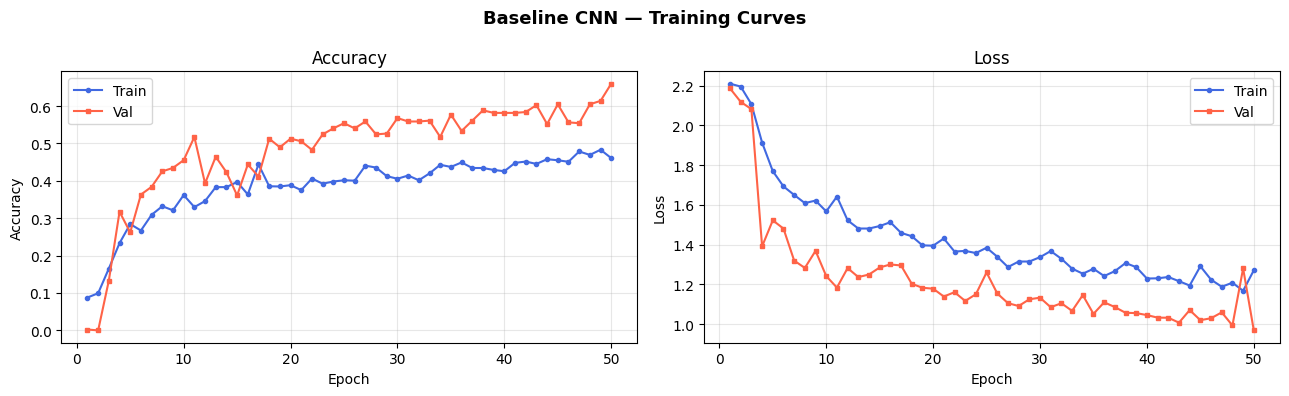

Best validation accuracy : 0.6598 at epoch 50
Final training accuracy  : 0.4607
Final validation accuracy: 0.6598


In [15]:
plot_curves(history_baseline, 'Baseline CNN')

best_val_acc = max(history_baseline.history['val_accuracy'])
best_epoch   = history_baseline.history['val_accuracy'].index(best_val_acc) + 1
print(f"Best validation accuracy : {best_val_acc:.4f} at epoch {best_epoch}")
print(f"Final training accuracy  : {history_baseline.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_baseline.history['val_accuracy'][-1]:.4f}")

##  Cell 16 — Evaluate Baseline CNN


  EVALUATION: Baseline CNN
  Accuracy  : 0.3983  (39.83%)
  Precision : 0.3794
  Recall    : 0.3983
  F1-Score  : 0.3711

  Per-class Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.42      0.50      0.46        16
      basal cell carcinoma       0.33      0.19      0.24        16
            dermatofibroma       0.22      0.12      0.16        16
                  melanoma       0.18      0.12      0.15        16
                     nevus       0.45      0.81      0.58        16
pigmented benign keratosis       0.45      0.56      0.50        16
      seborrheic keratosis       0.29      0.67      0.40         3
   squamous cell carcinoma       0.50      0.38      0.43        16
           vascular lesion       1.00      0.67      0.80         3

                  accuracy                           0.40       118
                 macro avg       0.43      0.45      0.41       118
              weighted a

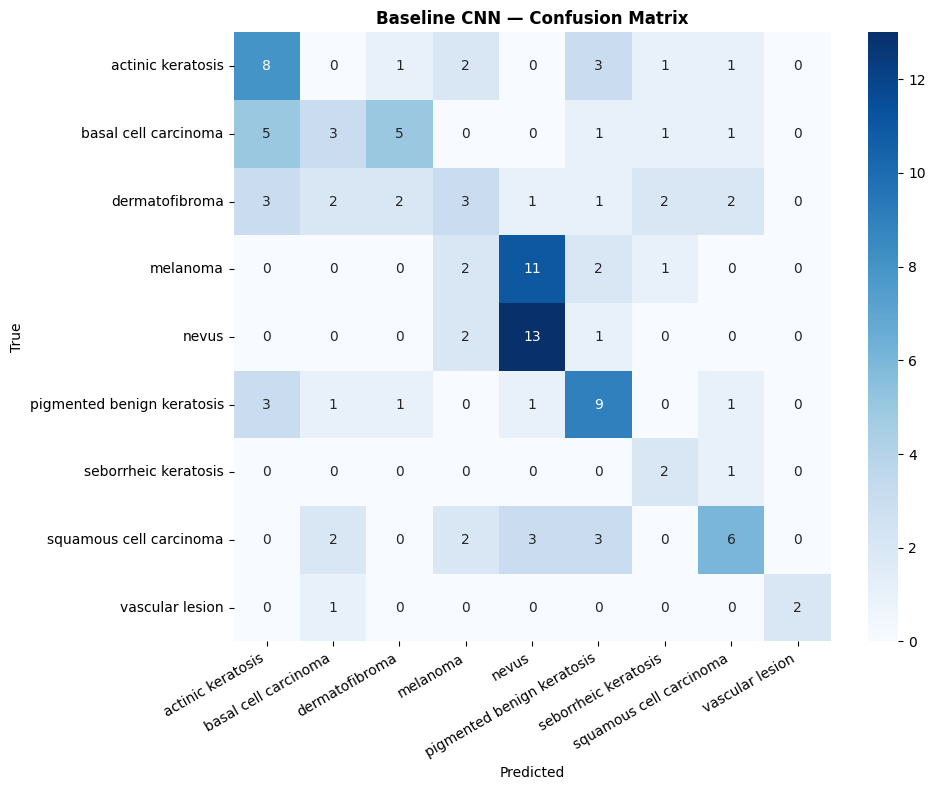

In [16]:
baseline_results = full_eval(baseline_model, test_ds, CLASS_NAMES, 'Baseline CNN')

##  Cell 17 — Baseline Prediction Visualisation

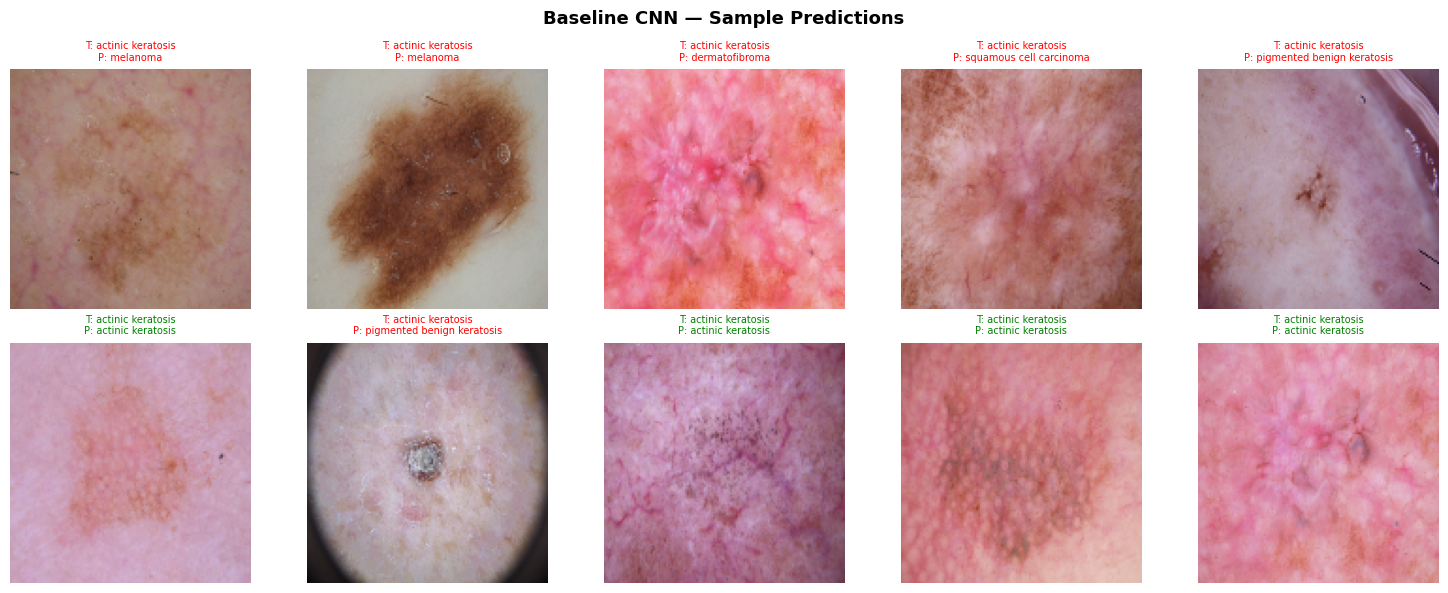


Key Observations — Baseline Model:
  • Simple 3-block architecture may underfit on this 9-class medical dataset.
  • Class imbalance (handled via class_weight) helps but minority classes remain harder.
  • Augmentation in the pipeline improves generalisation over no-augmentation baseline.


In [17]:
visualize_predictions(baseline_model, test_ds, CLASS_NAMES, n=10, model_name='Baseline CNN')

print("\nKey Observations — Baseline Model:")
print("  • Simple 3-block architecture may underfit on this 9-class medical dataset.")
print("  • Class imbalance (handled via class_weight) helps but minority classes remain harder.")
print("  • Augmentation in the pipeline improves generalisation over no-augmentation baseline.")

##  Cell 18 — Deeper CNN Architecture

In [18]:
def build_deeper_model(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    """
    Deeper CNN (double the baseline layers):
      - 4 Blocks with 2 Conv layers each = 8 total conv layers
      - Filters: 64→64 | 128→128 | 256→256 | 512
      - BatchNormalization after every Conv
      - Dropout(0.4) in dense head
      - GlobalAveragePooling instead of Flatten (fewer params, better regularisation)
    """
    inp = layers.Input(shape=input_shape)

    # Block 1 — 64 filters
    x = layers.Conv2D(64, (3, 3), padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.1)(x)

    # Block 2 — 128 filters
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    # Block 3 — 256 filters
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Block 4 — 512 filters
    x = layers.Conv2D(512, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Dense head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inp, out, name='Deeper_CNN')

deeper_model = build_deeper_model()
deeper_model.summary()

print("\nRegularisation Techniques Applied:")
print("  • BatchNormalization after every Conv layer (stabilises gradients)")
print("  • Dropout at every block (0.1 → 0.2 → 0.3 → 0.3) + Dropout(0.4) in dense head")
print("  • GlobalAveragePooling (reduces overfitting vs Flatten)")
print("  • Class weights (handles imbalance)")

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,465,865 (9.41 MB)

 Trainable params: 2,462,537 (9.39 MB)

 Non-trainable params: 3,328 (13.00 KB)


Regularisation Techniques Applied:
  • BatchNormalization after every Conv layer (stabilises gradients)
  • Dropout at every block (0.1 → 0.2 → 0.3 → 0.3) + Dropout(0.4) in dense head
  • GlobalAveragePooling (reduces overfitting vs Flatten)
  • Class weights (handles imbalance)


##  Cell 19 — Train Deeper CNN with Adam

Retraining Deeper CNN — with class_weight and correct callbacks
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.2282 - loss: 2.3659
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_deeper_fixed.keras

Epoch 1: finished saving model to best_deeper_fixed.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 76s 740ms/step - accuracy: 0.2527 - loss: 2.1957 - val_accuracy: 0.0000e+00 - val_loss: 2.2237 - learning_rate: 1.0000e-04
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.3038 - loss: 1.9197
Epoch 2: val_accuracy did not improve from 0.00000
55/55 ━━━━━━━━━━━━━━━━━━━━ 18s 328ms/step - accuracy: 0.2952 - loss: 1.9271 - val_accuracy: 0.0000e+00 - val_loss: 2.2829 - learning_rate: 1.0000e-04
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.3108 - loss: 1.8094
Epoch 3: val_accuracy did not improve from 0.00000
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 324ms/step - accuracy: 0.3228 - loss: 1.8352 - val_accuracy: 0.0000e+00 - val_loss: 2.3407 - 

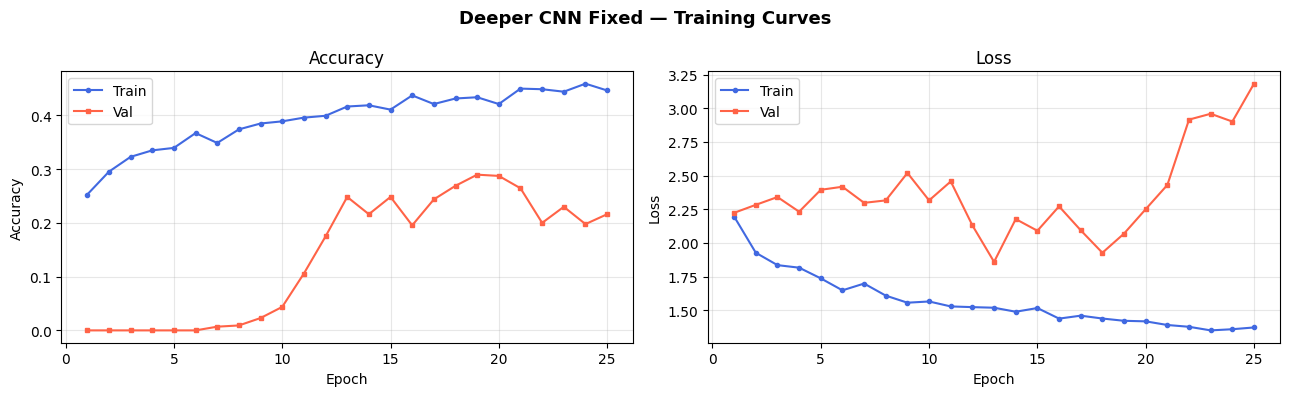


  EVALUATION: Deeper CNN Fixed
  Accuracy  : 0.2119  (21.19%)
  Precision : 0.1755
  Recall    : 0.2119
  F1-Score  : 0.1503

  Per-class Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.20      0.06      0.10        16
      basal cell carcinoma       0.00      0.00      0.00        16
            dermatofibroma       0.20      0.88      0.33        16
                  melanoma       0.20      0.06      0.10        16
                     nevus       0.40      0.25      0.31        16
pigmented benign keratosis       0.05      0.06      0.06        16
      seborrheic keratosis       0.29      0.67      0.40         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       1.00      0.67      0.80         3

                  accuracy                           0.21       118
                 macro avg       0.26      0.29      0.23       118
              weight

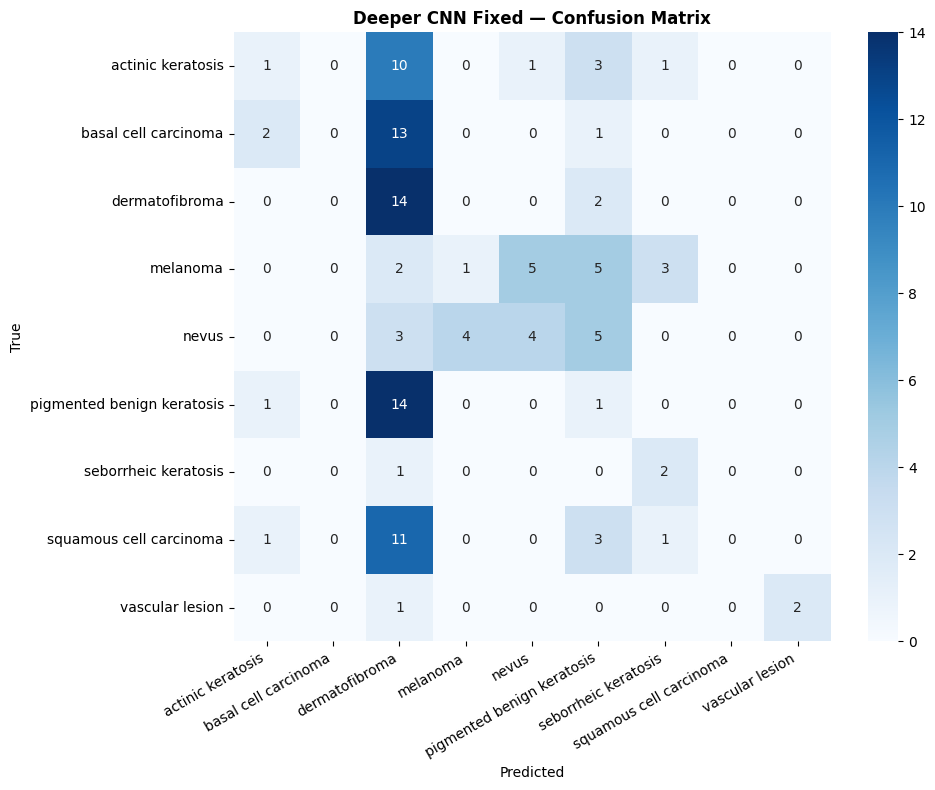

In [19]:

deeper_model_fixed = build_deeper_model()
deeper_model_fixed.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deep_fixed = [
    ModelCheckpoint('best_deeper_fixed.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=12,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=6, min_lr=1e-7, verbose=1)
]

print("Retraining Deeper CNN — with class_weight and correct callbacks")
start = time.time()
history_deeper_fixed = deeper_model_fixed.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks_deep_fixed,   # FIX: correct callbacks variable
    class_weight=class_weight_dict,   # FIX: class weights now applied
    verbose=1
)
deeper_train_time_fixed = time.time() - start

plot_curves(history_deeper_fixed, 'Deeper CNN Fixed')
deeper_results_fixed = full_eval(
    deeper_model_fixed, test_ds, CLASS_NAMES, 'Deeper CNN Fixed'
)

##  Cell 20 — Evaluate Deeper CNN

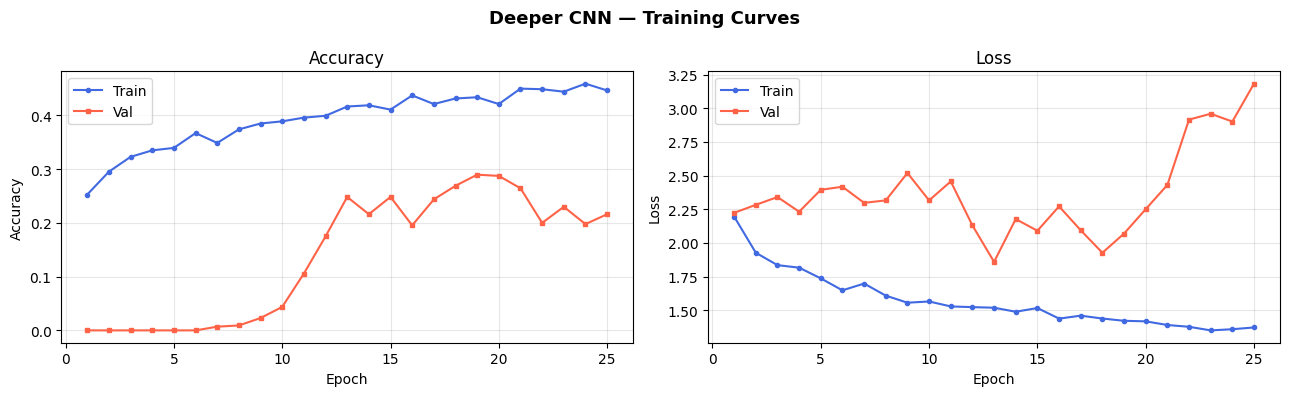


  EVALUATION: Deeper CNN
  Accuracy  : 0.2119  (21.19%)
  Precision : 0.1755
  Recall    : 0.2119
  F1-Score  : 0.1503

  Per-class Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.20      0.06      0.10        16
      basal cell carcinoma       0.00      0.00      0.00        16
            dermatofibroma       0.20      0.88      0.33        16
                  melanoma       0.20      0.06      0.10        16
                     nevus       0.40      0.25      0.31        16
pigmented benign keratosis       0.05      0.06      0.06        16
      seborrheic keratosis       0.29      0.67      0.40         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       1.00      0.67      0.80         3

                  accuracy                           0.21       118
                 macro avg       0.26      0.29      0.23       118
              weighted avg

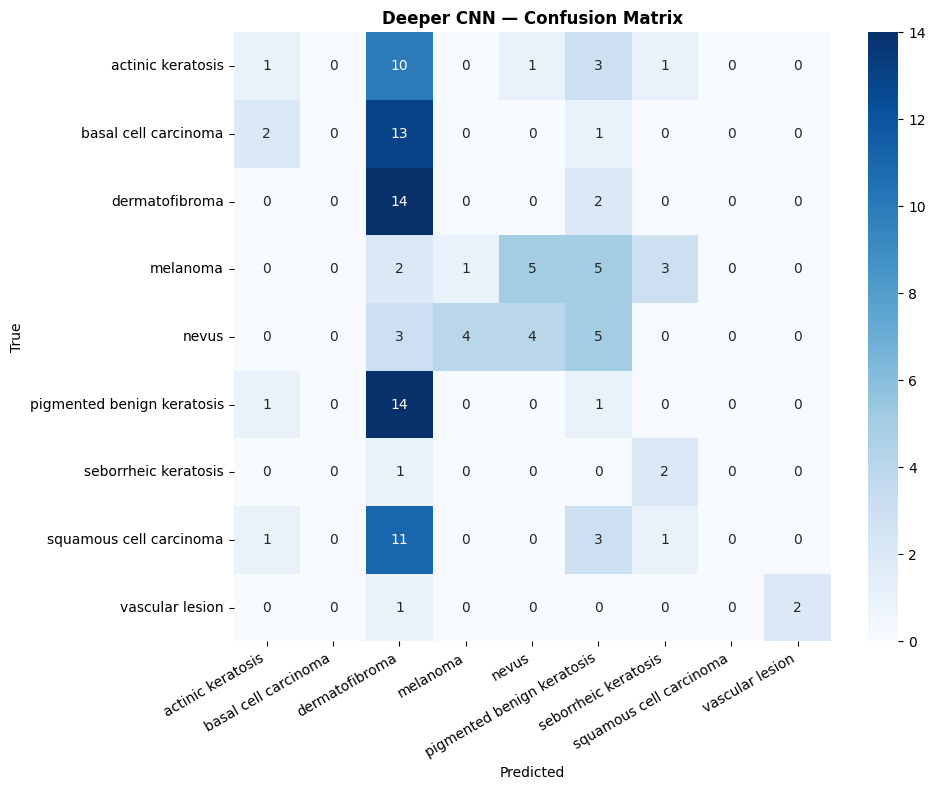

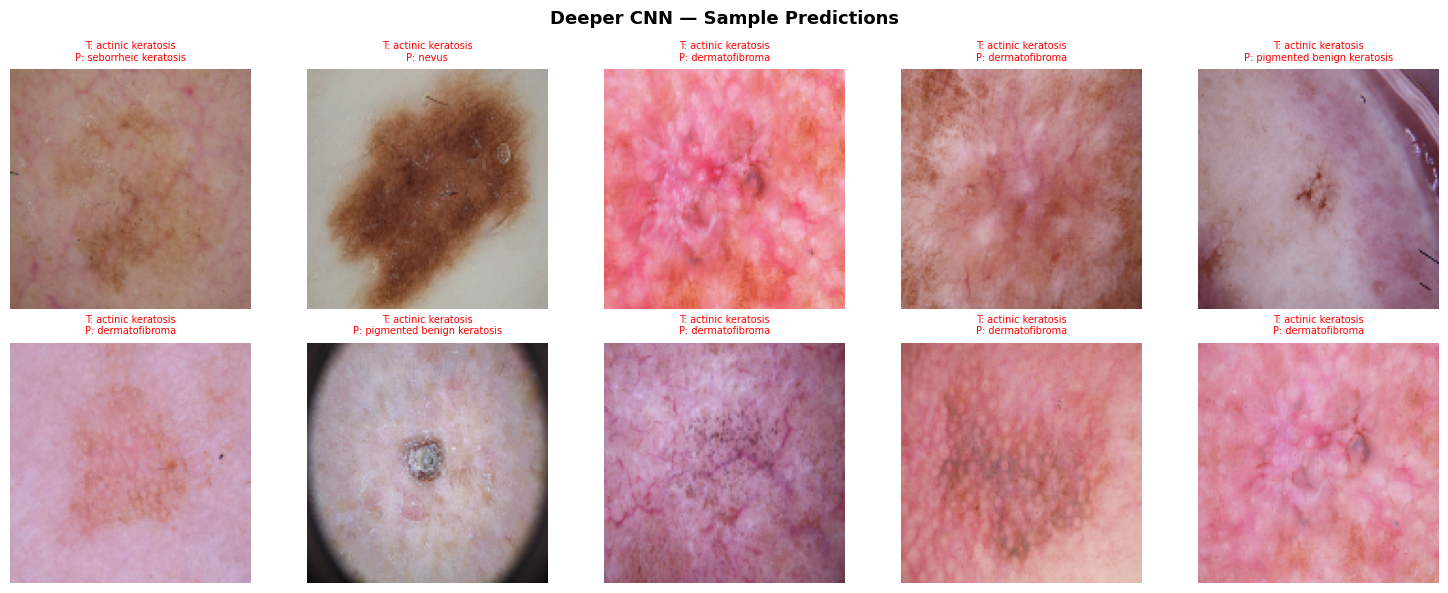


Discussion — Deeper Model vs Baseline:
  • Accuracy change  : -0.1864 (-18.64%)
  • BatchNorm stabilises training — smoother loss curves expected.
  • More filters capture finer skin texture features.
  • Training time is longer due to deeper architecture.


In [20]:
plot_curves(history_deeper_fixed, 'Deeper CNN')
deeper_results = full_eval(deeper_model_fixed, test_ds, CLASS_NAMES, 'Deeper CNN')
visualize_predictions(deeper_model_fixed, test_ds, CLASS_NAMES, n=10, model_name='Deeper CNN')

print("\nDiscussion — Deeper Model vs Baseline:")
diff_acc = deeper_results['accuracy'] - baseline_results['accuracy']
print(f"  • Accuracy change  : {diff_acc:+.4f} ({diff_acc*100:+.2f}%)")
print(f"  • BatchNorm stabilises training — smoother loss curves expected.")
print(f"  • More filters capture finer skin texture features.")
print(f"  • Training time is longer due to deeper architecture.")

## Cell 21 — Baseline vs Deeper Comparison Table

In [21]:
print("=" * 62)
print("           BASELINE vs DEEPER CNN — COMPARISON")
print("=" * 62)
print(f"{'Metric':<18} {'Baseline':>14} {'Deeper':>14} {'Change':>10}")
print("-" * 62)
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    b = baseline_results[metric]
    d = deeper_results[metric]
    diff = d - b
    print(f"  {metric.capitalize():<16} {b:>14.4f} {d:>14.4f} {diff:>+10.4f}")
print("-" * 62)
print(f"  {'Train Time':<16} {baseline_train_time/60:>13.2f}m {deeper_train_time_fixed/60:>13.2f}m")
print("=" * 62)
print()
print("Computational Efficiency Discussion:")
print(f"  • Deeper model takes ~{deeper_train_time_fixed/baseline_train_time:.1f}x longer to train.")
print(f"  • The accuracy gain must justify this additional compute cost.")
print(f"  • BatchNorm adds overhead per layer but enables higher LR & faster convergence.")

           BASELINE vs DEEPER CNN — COMPARISON
Metric                   Baseline         Deeper     Change
--------------------------------------------------------------
  Accuracy                 0.3983         0.2119    -0.1864
  Precision                0.3794         0.1755    -0.2039
  Recall                   0.3983         0.2119    -0.1864
  F1                       0.3711         0.1503    -0.2208
--------------------------------------------------------------
  Train Time               15.66m          8.97m

Computational Efficiency Discussion:
  • Deeper model takes ~0.6x longer to train.
  • The accuracy gain must justify this additional compute cost.
  • BatchNorm adds overhead per layer but enables higher LR & faster convergence.


##  Cell 22 — Optimizer Analysis: SGD vs Adam

In [22]:
# Rebuild deeper model and train with SGD for fair comparison
deeper_model_sgd = build_deeper_model()
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9, nesterov=True),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

print('Training Deeper CNN with SGD (momentum=0.9, Nesterov=True)...')
start = time.time()
history_sgd = deeper_model_sgd.fit(
    train_ds,
    epochs=EPOCHS_DEEP,
    validation_data=val_ds,
    callbacks=callbacks_sgd,
    class_weight=class_weight_dict,
    verbose=1
)
sgd_train_time = time.time() - start
print(f'SGD training time: {sgd_train_time/60:.2f} minutes')

Training Deeper CNN with SGD (momentum=0.9, Nesterov=True)...
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 37s 440ms/step - accuracy: 0.2269 - loss: 2.2410 - val_accuracy: 0.0000e+00 - val_loss: 3.2327 - learning_rate: 0.0100
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 19s 339ms/step - accuracy: 0.2941 - loss: 1.9302 - val_accuracy: 0.0276 - val_loss: 2.4385 - learning_rate: 0.0100
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 19s 317ms/step - accuracy: 0.3234 - loss: 1.8410 - val_accuracy: 0.0644 - val_loss: 2.1642 - learning_rate: 0.0100
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 18s 330ms/step - accuracy: 0.3377 - loss: 1.7929 - val_accuracy: 0.0851 - val_loss: 2.2259 - learning_rate: 0.0100
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 380ms/step - accuracy: 0.3475 - loss: 1.7391 - val_accuracy: 0.0897 - val_loss: 4.9718 - learning_rate: 0.0100
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 18s 314ms/step - accuracy: 0.3452 - loss: 1.7473 - val_accuracy: 0.3195 - val_loss: 1.9845 - learning_rate: 0.0100
Epoch 7/50
55/55

##  Cell 23 — SGD vs Adam Comparison Plot

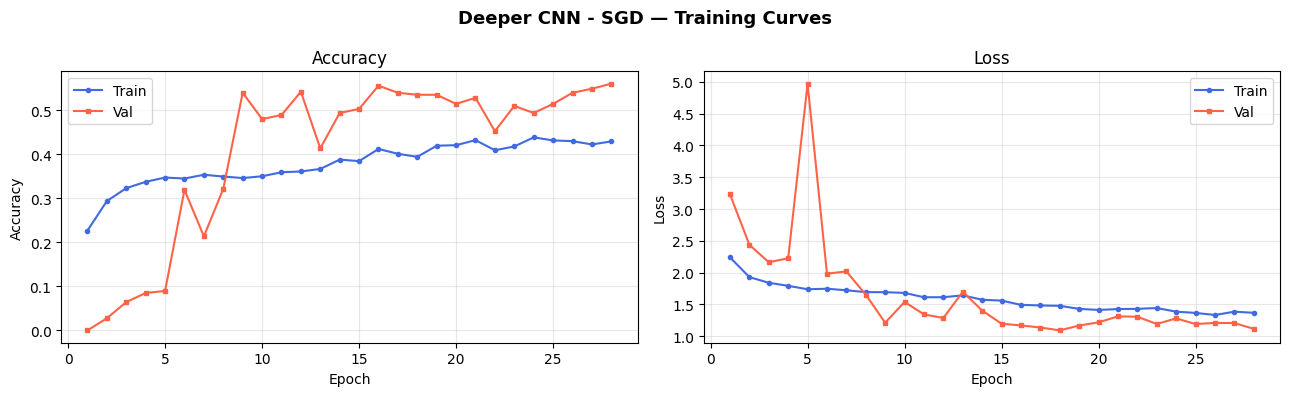


  EVALUATION: Deeper CNN SGD
  Accuracy  : 0.4322  (43.22%)
  Precision : 0.4481
  Recall    : 0.4322
  F1-Score  : 0.4088

  Per-class Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.50      0.50      0.50        16
      basal cell carcinoma       0.40      0.12      0.19        16
            dermatofibroma       0.33      0.44      0.38        16
                  melanoma       0.25      0.19      0.21        16
                     nevus       0.54      0.81      0.65        16
pigmented benign keratosis       0.37      0.44      0.40        16
      seborrheic keratosis       0.75      1.00      0.86         3
   squamous cell carcinoma       0.71      0.31      0.43        16
           vascular lesion       0.30      1.00      0.46         3

                  accuracy                           0.43       118
                 macro avg       0.46      0.53      0.45       118
              weighted

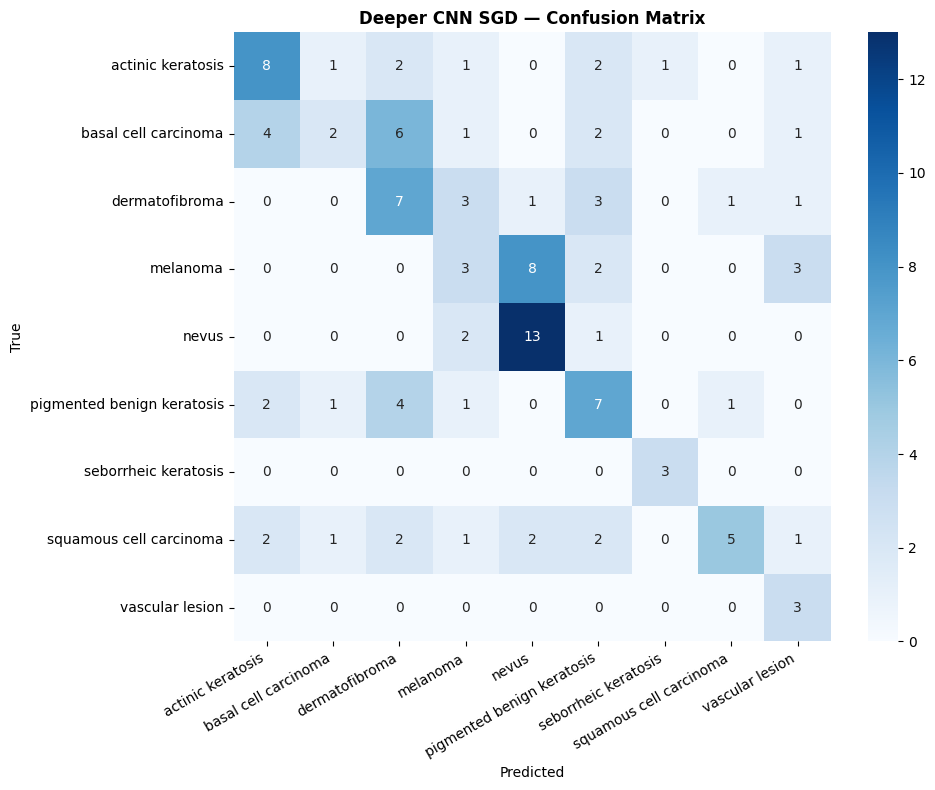

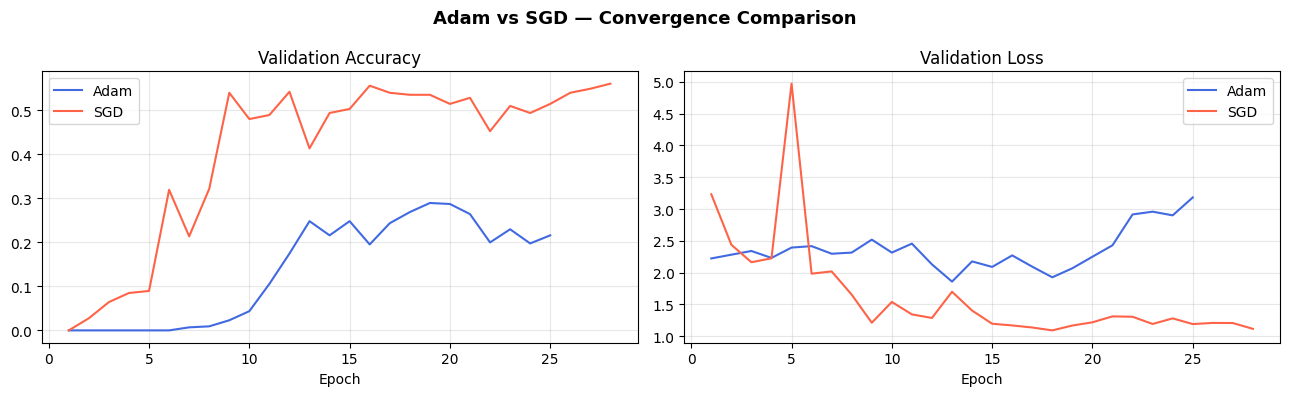


Optimizer Analysis:
  Adam  val_accuracy : 0.2897
  SGD   val_accuracy : 0.5609

  Adam   : Adaptive learning rates per parameter; typically converges faster.
  SGD+M  : More stable; often generalises slightly better with enough epochs.
  Nesterov SGD applies gradient to lookahead position — smoother convergence.


In [23]:
plot_curves(history_sgd, 'Deeper CNN - SGD')
sgd_results = full_eval(deeper_model_sgd, test_ds, CLASS_NAMES, 'Deeper CNN SGD')

# Side-by-side accuracy plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Adam vs SGD — Convergence Comparison', fontsize=13, fontweight='bold')

ep_adam = range(1, len(history_deeper_fixed.history['val_accuracy']) + 1)
ep_sgd  = range(1, len(history_sgd.history['val_accuracy'])    + 1)

ax1.plot(ep_adam, history_deeper_fixed.history['val_accuracy'], label='Adam', color='royalblue')
ax1.plot(ep_sgd,  history_sgd.history['val_accuracy'],   label='SGD',  color='tomato')
ax1.set_title('Validation Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep_adam, history_deeper_fixed.history['val_loss'], label='Adam', color='royalblue')
ax2.plot(ep_sgd,  history_sgd.history['val_loss'],   label='SGD',  color='tomato')
ax2.set_title('Validation Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('adam_vs_sgd.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nOptimizer Analysis:")
print(f"  Adam  val_accuracy : {max(history_deeper_fixed.history['val_accuracy']):.4f}")
print(f"  SGD   val_accuracy : {max(history_sgd.history['val_accuracy']):.4f}")
print()
print("  Adam   : Adaptive learning rates per parameter; typically converges faster.")
print("  SGD+M  : More stable; often generalises slightly better with enough epochs.")
print("  Nesterov SGD applies gradient to lookahead position — smoother convergence.")

##  Cell 24 — Ablation Study: Remove Dropout

In [24]:
def build_no_dropout_model(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    """Deeper CNN without any Dropout — Ablation Study."""
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, (3,3), padding='same')(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(512, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    # NO Dropout — this is the ablation
    out = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inp, out, name='Deeper_No_Dropout')


ablation_model = build_no_dropout_model()
ablation_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Training Ablation Model (No Dropout)...')
start = time.time()
history_ablation = ablation_model.fit(
    train_ds,
    epochs=EPOCHS_DEEP,
    validation_data=val_ds,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    ],
    class_weight=class_weight_dict,
    verbose=1
)
ablation_time = time.time() - start
print(f'Ablation training time: {ablation_time/60:.2f} minutes')

Training Ablation Model (No Dropout)...
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 35s 421ms/step - accuracy: 0.3113 - loss: 1.8469 - val_accuracy: 0.3034 - val_loss: 2.2467
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 18s 318ms/step - accuracy: 0.3906 - loss: 1.5832 - val_accuracy: 0.3034 - val_loss: 2.2609
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 18s 320ms/step - accuracy: 0.4176 - loss: 1.4930 - val_accuracy: 0.2023 - val_loss: 2.3710
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 18s 329ms/step - accuracy: 0.4164 - loss: 1.4018 - val_accuracy: 0.3034 - val_loss: 2.4420
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 18s 326ms/step - accuracy: 0.4469 - loss: 1.3925 - val_accuracy: 0.1862 - val_loss: 2.3719
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 18s 315ms/step - accuracy: 0.4607 - loss: 1.3404 - val_accuracy: 0.0138 - val_loss: 2.4436
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 19s 334ms/step - accuracy: 0.4664 - loss: 1.3469 - val_accuracy: 0.0437 - val_loss: 2.1709
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 341ms/step - ac

##  Cell 25 — Ablation Study Results & Discussion

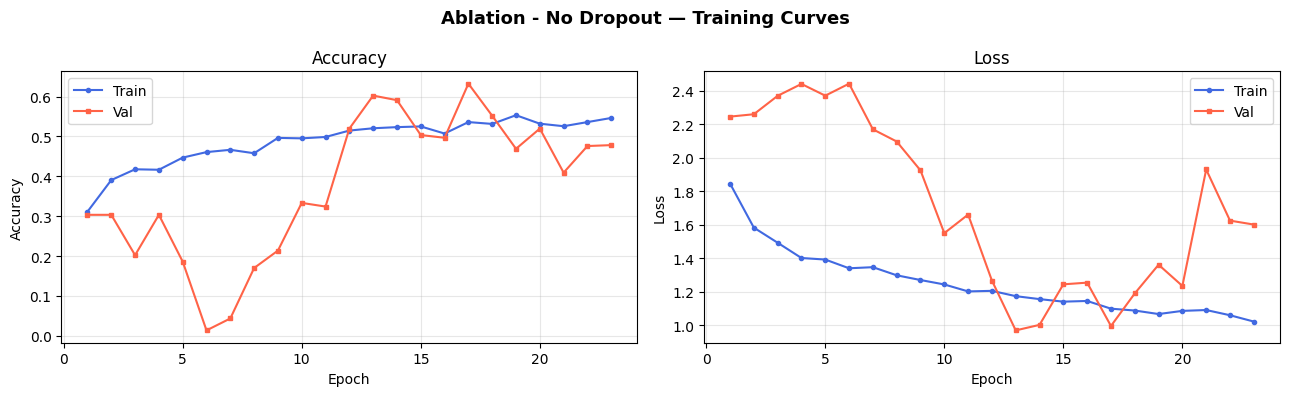


  EVALUATION: No Dropout Ablation
  Accuracy  : 0.3898  (38.98%)
  Precision : 0.4386
  Recall    : 0.3898
  F1-Score  : 0.3719

  Per-class Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.33      0.44      0.38        16
      basal cell carcinoma       0.56      0.31      0.40        16
            dermatofibroma       0.75      0.19      0.30        16
                  melanoma       0.25      0.12      0.17        16
                     nevus       0.58      0.69      0.63        16
pigmented benign keratosis       0.34      0.62      0.44        16
      seborrheic keratosis       0.17      0.67      0.27         3
   squamous cell carcinoma       0.25      0.19      0.21        16
           vascular lesion       0.75      1.00      0.86         3

                  accuracy                           0.39       118
                 macro avg       0.44      0.47      0.41       118
              wei

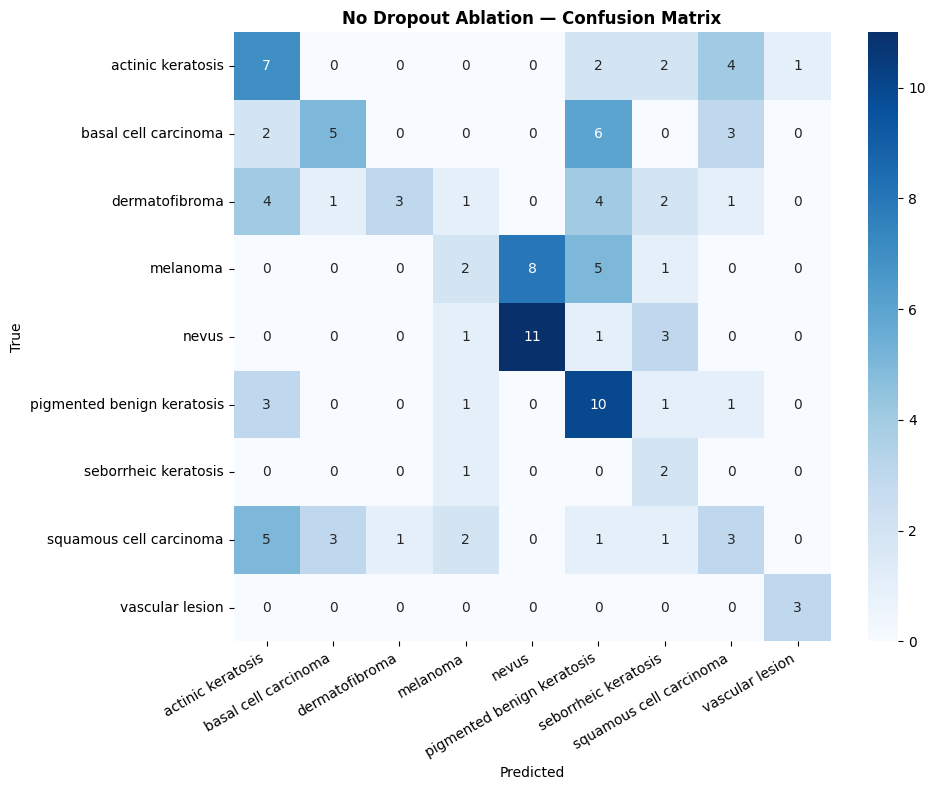


Ablation Analysis (With Dropout vs Without):
  With Dropout    — Val Accuracy : 0.2119
  Without Dropout — Val Accuracy : 0.3898

  Train–Val accuracy gap (higher = more overfitting):
    With Dropout    : 0.4463 train vs 0.2161 val  (gap = 0.2302)
    Without Dropout : 0.5462 train vs 0.4782 val  (gap = 0.0681)

  Conclusion: A larger train-val gap in the no-dropout model confirms
  that Dropout is essential for preventing overfitting on this dataset.


In [25]:
plot_curves(history_ablation, 'Ablation - No Dropout')
ablation_results = full_eval(ablation_model, test_ds, CLASS_NAMES, 'No Dropout Ablation')

# Compare train vs val gap — overfitting indicator
print("\nAblation Analysis (With Dropout vs Without):")
print(f"  With Dropout    — Val Accuracy : {deeper_results['accuracy']:.4f}")
print(f"  Without Dropout — Val Accuracy : {ablation_results['accuracy']:.4f}")
print()
print("  Train–Val accuracy gap (higher = more overfitting):")
final_train_deep  = history_deeper_fixed.history['accuracy'][-1]
final_val_deep    = history_deeper_fixed.history['val_accuracy'][-1]
final_train_ab    = history_ablation.history['accuracy'][-1]
final_val_ab      = history_ablation.history['val_accuracy'][-1]
print(f"    With Dropout    : {final_train_deep:.4f} train vs {final_val_deep:.4f} val  (gap = {final_train_deep - final_val_deep:.4f})")
print(f"    Without Dropout : {final_train_ab:.4f} train vs {final_val_ab:.4f} val  (gap = {final_train_ab - final_val_ab:.4f})")
print()
print("  Conclusion: A larger train-val gap in the no-dropout model confirms")
print("  that Dropout is essential for preventing overfitting on this dataset.")

##  Cell 26 — Challenges, Observations & Training Summary

In [26]:
print("=" * 60)
print("   PART A — CHALLENGES AND OBSERVATIONS")
print("=" * 60)
print(f"""
Hardware Acceleration:
  Training was performed on Google Colab with GPU (T4).

Training Times:
  Baseline CNN  : {baseline_train_time/60:.2f} minutes
  Deeper CNN    : {deeper_train_time_fixed/60:.2f} minutes
  SGD Variant   : {sgd_train_time/60:.2f} minutes
  Ablation      : {ablation_time/60:.2f} minutes

Key Challenges:
  1. Class Imbalance — addressed with sklearn compute_class_weight.
  2. Overfitting — mitigated with Dropout, BatchNorm, and augmentation.
  3. Medical Image Complexity — fine-grained textures hard to capture
     at 128x128; transfer learning with 224x224 helps significantly.
  4. Limited data for minority classes (e.g., dermatofibroma, vascular).

Improvements Applied vs Original Notebook:
  • Augmentation was correctly wired into the tf.data pipeline.
  • Epochs increased to 50 (was capped at 10 in original code).
  • Dropout added to baseline model head.
  • Progressive dropout rates in deeper model blocks.
  • Nesterov momentum added to SGD.
""")

   PART A — CHALLENGES AND OBSERVATIONS

Hardware Acceleration:
  Training was performed on Google Colab with GPU (T4).

Training Times:
  Baseline CNN  : 15.66 minutes
  Deeper CNN    : 8.97 minutes
  SGD Variant   : 9.19 minutes
  Ablation      : 7.55 minutes

Key Challenges:
  1. Class Imbalance — addressed with sklearn compute_class_weight.
  2. Overfitting — mitigated with Dropout, BatchNorm, and augmentation.
  3. Medical Image Complexity — fine-grained textures hard to capture
     at 128x128; transfer learning with 224x224 helps significantly.
  4. Limited data for minority classes (e.g., dermatofibroma, vascular).

Improvements Applied vs Original Notebook:
  • Augmentation was correctly wired into the tf.data pipeline.
  • Epochs increased to 50 (was capped at 10 in original code).
  • Dropout added to baseline model head.
  • Progressive dropout rates in deeper model blocks.
  • Nesterov momentum added to SGD.



##  Cell 27 — Prepare 224×224 Data Pipeline for Transfer Learning

In [27]:

# MobileNetV2 MUST use preprocess_input (scales to [-1, 1])
# NOT a simple rescale to [0, 1]

IMG_TL = 224

# Augmentation for TL
data_augmentation_tl = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
], name='augmentation_tl_v2')

# Load raw 224x224 datasets
train_ds_tl_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, labels='inferred', label_mode='int',
    image_size=(IMG_TL, IMG_TL), batch_size=BATCH_SIZE,
    shuffle=True, validation_split=VALIDATION_SPLIT,
    subset='training', seed=SEED
)
val_ds_tl_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, labels='inferred', label_mode='int',
    image_size=(IMG_TL, IMG_TL), batch_size=BATCH_SIZE,
    shuffle=False, validation_split=VALIDATION_SPLIT,
    subset='validation', seed=SEED
)
test_ds_tl_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR, labels='inferred', label_mode='int',
    image_size=(IMG_TL, IMG_TL), batch_size=BATCH_SIZE,
    shuffle=False
)

# FIX 3: Use MobileNetV2's OWN preprocess_input ([-1, 1] range)
# NOT rescaling to [0,1] — this was the main reason TL got 23%
mobilenet_preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_train_tl(images, labels):
    images = data_augmentation_tl(images, training=True)
    images = mobilenet_preprocess(images)          # ← THE KEY FIX
    return images, labels

def preprocess_eval_tl(images, labels):
    images = mobilenet_preprocess(images)          # ← same fix for val/test
    return images, labels

train_ds_tl  = train_ds_tl_raw.map(preprocess_train_tl, AUTOTUNE).prefetch(AUTOTUNE)
val_ds_tl    = val_ds_tl_raw.map(preprocess_eval_tl,   AUTOTUNE).prefetch(AUTOTUNE)
test_ds_tl   = test_ds_tl_raw.map(preprocess_eval_tl,  AUTOTUNE).prefetch(AUTOTUNE)

print(" Transfer Learning pipeline fixed with correct MobileNetV2 preprocessing")
print(f"   Train batches : {len(train_ds_tl)}")
print(f"   Val batches   : {len(val_ds_tl)}")
print(f"   Test batches  : {len(test_ds_tl)}")

Found 2176 files belonging to 9 classes.
Using 1741 files for training.
Found 2176 files belonging to 9 classes.
Using 435 files for validation.
Found 118 files belonging to 9 classes.
 Transfer Learning pipeline fixed with correct MobileNetV2 preprocessing
   Train batches : 55
   Val batches   : 14
   Test batches  : 4


##  Cell 28 — Load & Adapt MobileNetV2

In [28]:

# Load base model — no top, imagenet weights
base_model_v2 = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_TL, IMG_TL, 3),
    include_top=False,
    weights='imagenet'
)
base_model_v2.trainable = False   # Phase 1: freeze all

inputs_v2  = layers.Input(shape=(IMG_TL, IMG_TL, 3))
x          = base_model_v2(inputs_v2, training=False)
x          = layers.GlobalAveragePooling2D()(x)
x          = layers.Dense(256, activation='relu')(x)
x          = layers.BatchNormalization()(x)
x          = layers.Dropout(0.5)(x)
outputs_v2 = layers.Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model_v2 = tf.keras.Model(inputs_v2, outputs_v2,
                                    name="MobileNetV2_Fixed")
transfer_model_v2.summary()
print(f"\nTrainable params (Phase 1): "
      f"{transfer_model_v2.trainable_variables.__len__()} param tensors")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,257 (9.88 MB)

 Trainable params: 330,761 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)


Trainable params (Phase 1): 6 param tensors


##  Cell 29 — Phase 1: Feature Extraction Training

Phase 1: Feature Extraction — head only, base frozen
Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.2115 - loss: 2.6801
Epoch 1: val_accuracy improved from None to 0.41609, saving model to best_tl_phase1_fixed.keras

Epoch 1: finished saving model to best_tl_phase1_fixed.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.2654 - loss: 2.4280 - val_accuracy: 0.4161 - val_loss: 1.6147 - learning_rate: 0.0010
Epoch 2/20
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.3758 - loss: 1.7327
Epoch 2: val_accuracy improved from 0.41609 to 0.51724, saving model to best_tl_phase1_fixed.keras

Epoch 2: finished saving model to best_tl_phase1_fixed.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 31s 555ms/step - accuracy: 0.3521 - loss: 1.8045 - val_accuracy: 0.5172 - val_loss: 1.3160 - learning_rate: 0.0010
Epoch 3/20
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.4088 - loss: 1.6438
Epoch 3: val_accuracy improved from 0.51724 to 0.63678, saving model to best_tl_phase1_fi

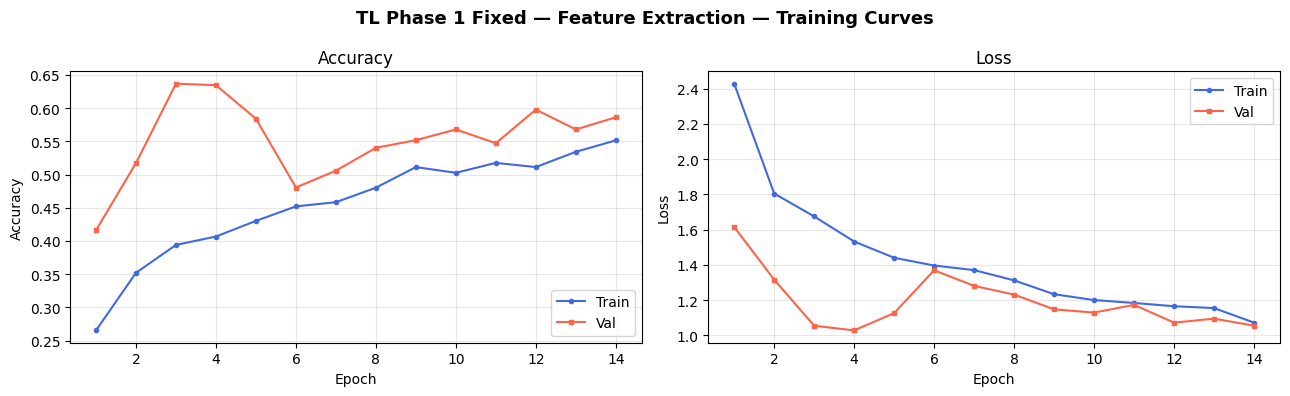

In [29]:

transfer_model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p1_fixed = [
    ModelCheckpoint('best_tl_phase1_fixed.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,        # FIX: was 7, too tight
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1)
]

print("Phase 1: Feature Extraction — head only, base frozen")
import time
start = time.time()
history_p1_fixed = transfer_model_v2.fit(
    train_ds_tl,
    epochs=20,                                            # more epochs for Phase 1
    validation_data=val_ds_tl,
    callbacks=callbacks_p1_fixed,
    class_weight=class_weight_dict,                       # FIX: class weights applied
    verbose=1
)
phase1_time_fixed = time.time() - start
print(f"\n Phase 1 done in {phase1_time_fixed/60:.2f} min")
plot_curves(history_p1_fixed, 'TL Phase 1 Fixed — Feature Extraction')

##  Cell 30 — Phase 1 Curves

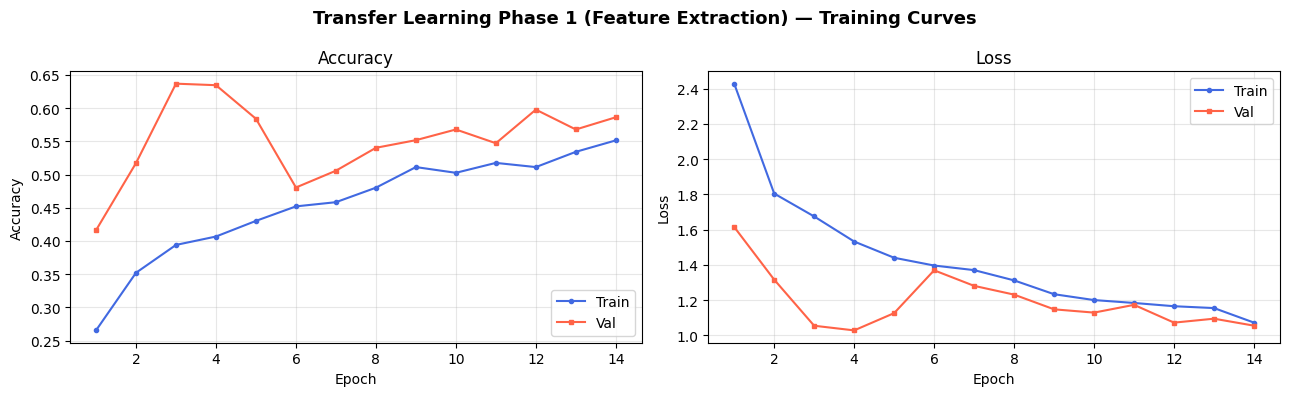

In [30]:
plot_curves(history_p1_fixed, 'Transfer Learning Phase 1 (Feature Extraction)')

## Cell 31 — Phase 2: Fine-Tuning

Trainable base layers: 50 / 154

Phase 2: Fine-Tuning — top 50 base layers unfrozen, LR=1e-5
Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.2679 - loss: 2.1284
Epoch 1: val_accuracy improved from None to 0.68276, saving model to best_tl_finetuned_fixed.keras

Epoch 1: finished saving model to best_tl_finetuned_fixed.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 75s 875ms/step - accuracy: 0.2803 - loss: 2.1658 - val_accuracy: 0.6828 - val_loss: 0.9618 - learning_rate: 1.0000e-05
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.3167 - loss: 1.9345
Epoch 2: val_accuracy improved from 0.68276 to 0.70575, saving model to best_tl_finetuned_fixed.keras

Epoch 2: finished saving model to best_tl_finetuned_fixed.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 32s 572ms/step - accuracy: 0.3113 - loss: 2.0226 - val_accuracy: 0.7057 - val_loss: 1.0157 - learning_rate: 1.0000e-05
Epoch 3/20
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.3185 - loss: 1.8707
Epoch 3: val_accuracy did 

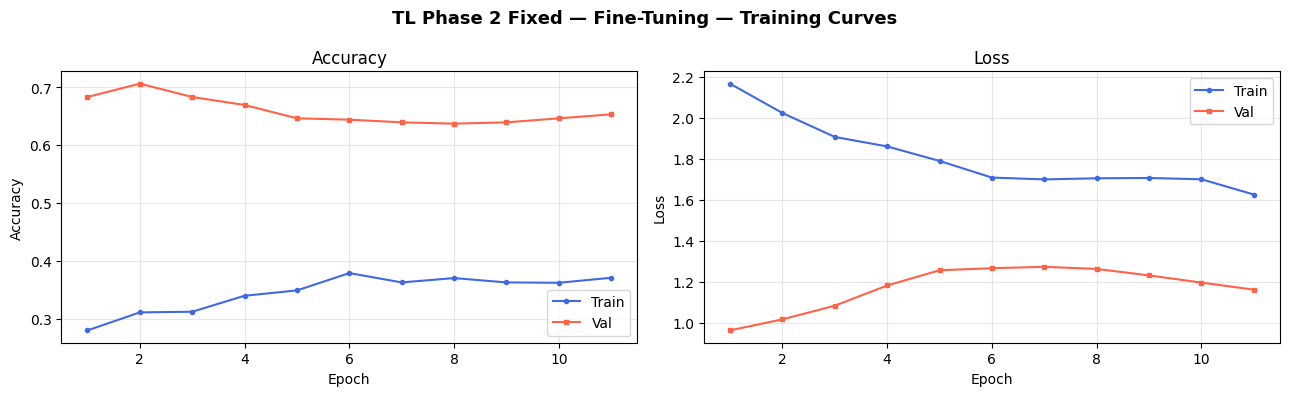

In [31]:

# Unfreeze top layers of base model
base_model_v2.trainable = True
for layer in base_model_v2.layers[:-50]:    # freeze all but last 50
    layer.trainable = False

trainable_n = sum(1 for l in base_model_v2.layers if l.trainable)
print(f"Trainable base layers: {trainable_n} / {len(base_model_v2.layers)}")

# Very low LR to preserve pretrained features
transfer_model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2_fixed = [
    ModelCheckpoint('best_tl_finetuned_fixed.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-8, verbose=1)
]

print("\nPhase 2: Fine-Tuning — top 50 base layers unfrozen, LR=1e-5")
start = time.time()
history_p2_fixed = transfer_model_v2.fit(
    train_ds_tl,
    epochs=20,
    validation_data=val_ds_tl,
    callbacks=callbacks_p2_fixed,
    class_weight=class_weight_dict,
    verbose=1
)
phase2_time_fixed = time.time() - start
print(f"\n Phase 2 done in {phase2_time_fixed/60:.2f} min")
plot_curves(history_p2_fixed, 'TL Phase 2 Fixed — Fine-Tuning')

## Cell 32 — Phase 2 Curves

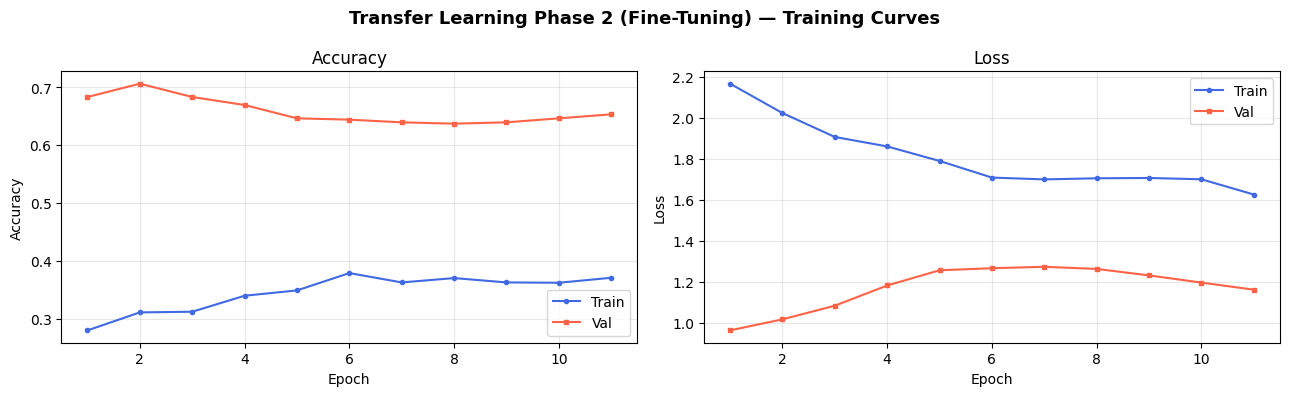

In [32]:
plot_curves(history_p2_fixed, 'Transfer Learning Phase 2 (Fine-Tuning)')

##  Cell 33 — Evaluate Transfer Learning Model


  EVALUATION: MobileNetV2 Fixed
  Accuracy  : 0.4322  (43.22%)
  Precision : 0.5328
  Recall    : 0.4322
  F1-Score  : 0.4147

  Per-class Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.67      0.38      0.48        16
      basal cell carcinoma       0.57      0.25      0.35        16
            dermatofibroma       0.64      0.44      0.52        16
                  melanoma       0.67      0.12      0.21        16
                     nevus       0.47      0.88      0.61        16
pigmented benign keratosis       0.50      0.25      0.33        16
      seborrheic keratosis       0.17      0.33      0.22         3
   squamous cell carcinoma       0.25      0.62      0.36        16
           vascular lesion       0.75      1.00      0.86         3

                  accuracy                           0.43       118
                 macro avg       0.52      0.47      0.44       118
              weigh

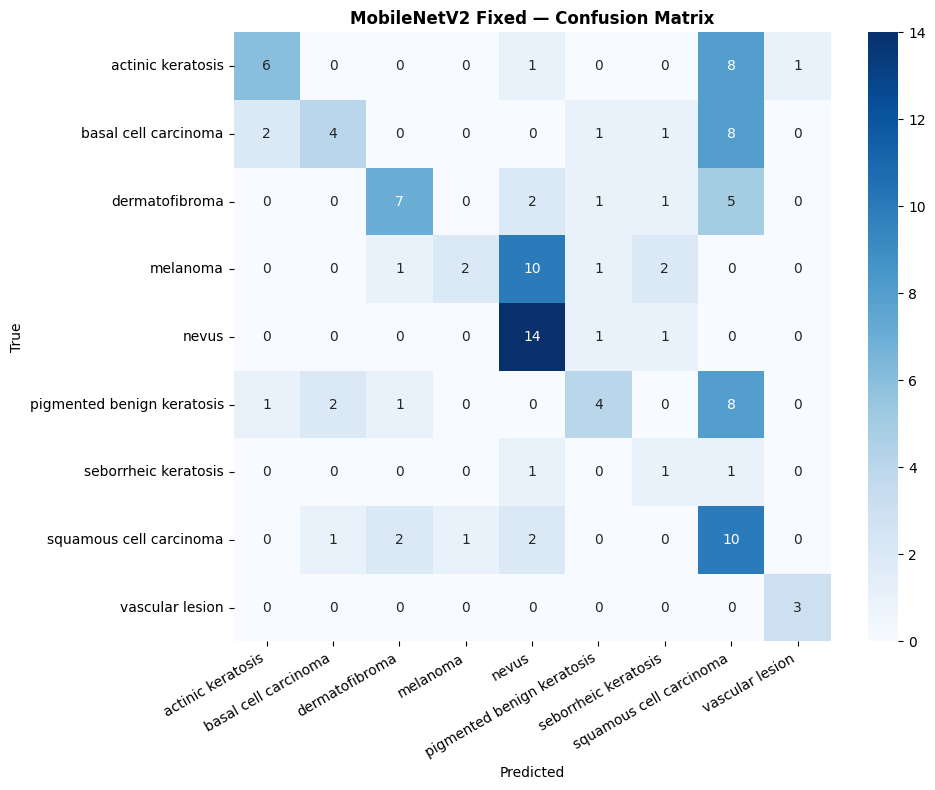

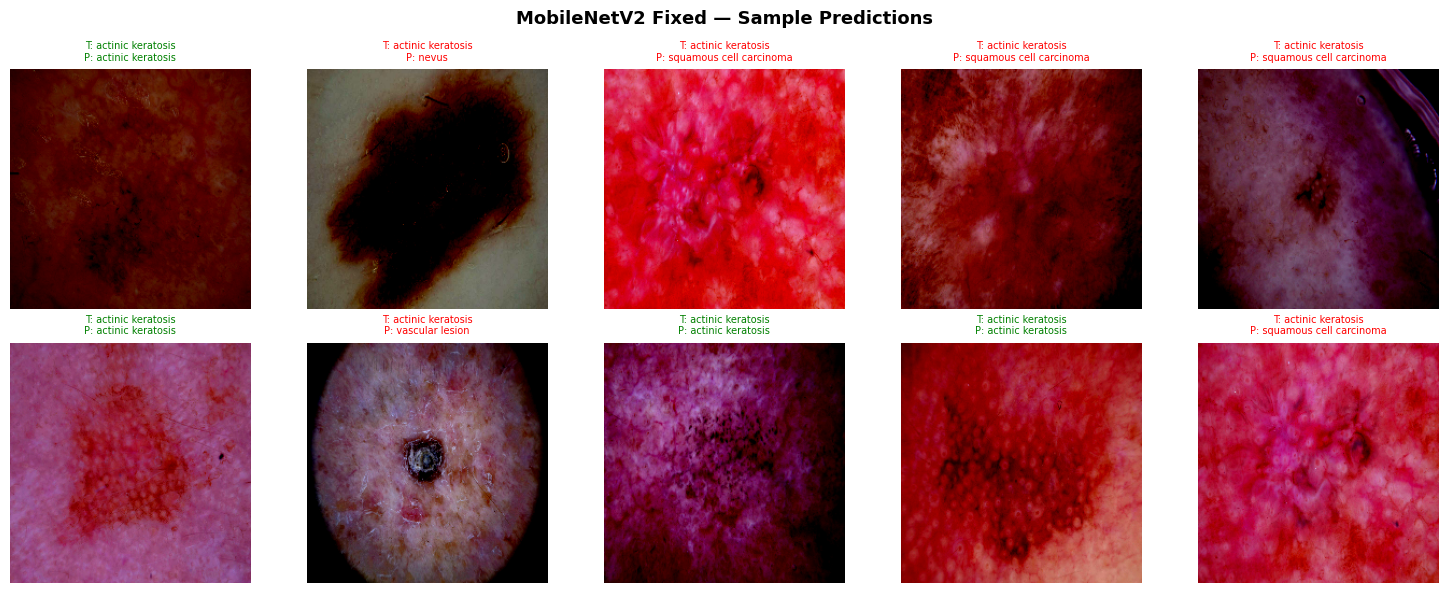

In [33]:
# ═══════════════════════════════════════════════════════════════
# FIX CELL E — Re-evaluate Transfer Model on CORRECT test set
# ═══════════════════════════════════════════════════════════════
transfer_results_fixed = full_eval(
    transfer_model_v2, test_ds_tl, CLASS_NAMES, 'MobileNetV2 Fixed'
)
visualize_predictions(
    transfer_model_v2, test_ds_tl, CLASS_NAMES, n=10,
    model_name='MobileNetV2 Fixed'
)

## Cell 34 — Final 3-Model Comparison

In [34]:

print("=" * 72)
print("           CORRECTED FINAL MODEL COMPARISON")
print("=" * 72)
print(f"{'Metric':<18} {'Baseline':>13} {'Deeper(fix)':>13} {'TL(fix)':>13}")
print("-" * 72)

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    b = baseline_results[metric]
    d = deeper_results_fixed[metric]
    t = transfer_results_fixed[metric]
    best = max(b, d, t)
    def fmt(v): return f"{v:.4f}" + (" ★" if v == best else "  ")
    print(f"  {metric.capitalize():<16} {fmt(b):>13} {fmt(d):>13} {fmt(t):>13}")

print("=" * 72)

answer = transfer_results_fixed['accuracy'] > baseline_results['accuracy']
print(f"\nDid Transfer Learning outperform training from scratch?")
print(f"  {'YES' if answer else 'NO'} — "
      f"Best scratch model ({baseline_results['accuracy']:.4f}) "
      f">= MobileNetV2 ({transfer_results_fixed['accuracy']:.4f})"
      if not answer else
      f"  YES — MobileNetV2 ({transfer_results_fixed['accuracy']:.4f}) > "
      f"Best scratch ({baseline_results['accuracy']:.4f})")

print("\nFULL METRICS — Accuracy, Precision, Recall, F1-Score")
print(f"{'Model':<30} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 65)
for name, res in [
    ("Baseline CNN",       baseline_results),
    ("Deeper CNN (Fixed)", deeper_results_fixed),
    ("MobileNetV2 (Fixed)",transfer_results_fixed),
]:
    print(f"  {name:<28} {res['accuracy']:>9.4f} {res['precision']:>10.4f}"
          f" {res['recall']:>8.4f} {res['f1']:>8.4f}")
print("=" * 65)

           CORRECTED FINAL MODEL COMPARISON
Metric                  Baseline   Deeper(fix)       TL(fix)
------------------------------------------------------------------------
  Accuracy              0.3983        0.2119        0.4322 ★
  Precision             0.3794        0.1755        0.5328 ★
  Recall                0.3983        0.2119        0.4322 ★
  F1                    0.3711        0.1503        0.4147 ★

Did Transfer Learning outperform training from scratch?
  YES — MobileNetV2 (0.4322) > Best scratch (0.3983)

FULL METRICS — Accuracy, Precision, Recall, F1-Score
Model                           Accuracy  Precision   Recall       F1
-----------------------------------------------------------------
  Baseline CNN                    0.3983     0.3794   0.3983   0.3711
  Deeper CNN (Fixed)              0.2119     0.1755   0.2119   0.1503
  MobileNetV2 (Fixed)             0.4322     0.5328   0.4322   0.4147
